In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/processed")

nav = pd.read_csv(DATA_DIR / "cleaned_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"], errors="coerce")

print("Shape:", nav.shape)
print("Funds:", nav["amfi_code"].nunique())
print("Date range:", nav["date"].min(), "to", nav["date"].max())

Shape: (46000, 3)
Funds: 40
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [2]:
missing = nav.isnull().sum()

print("Missing Values:")
display(missing[missing > 0])

if missing.sum() == 0:
    print("✅ No missing values found.")

Missing Values:


Series([], dtype: int64)

✅ No missing values found.


In [3]:
print("Duplicate rows:", nav.duplicated().sum())

duplicate_keys = nav.duplicated(
    subset=["amfi_code", "date"]
).sum()

print("Duplicate fund-date records:", duplicate_keys)

if duplicate_keys == 0:
    print("✅ No duplicate fund-date records found.")

Duplicate rows: 0
Duplicate fund-date records: 0
✅ No duplicate fund-date records found.


In [4]:
print("NAV Descriptive Statistics")

display(
    nav["nav"].describe().to_frame("NAV Statistics")
)

NAV Descriptive Statistics


,NAV Statistics
count,46000.000000
mean,269.570265
std,577.187060
min,26.136600
25%,69.170425
50%,122.732150
75%,260.338675
max,4268.549700


In [5]:
print("NAV Distribution by Percentiles")

percentiles = nav["nav"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(percentiles.to_frame("NAV"))

NAV Distribution by Percentiles


,NAV
0.01,28.337192
0.05,34.774910
0.10,47.735070
0.25,69.170425
0.50,122.732150
0.75,260.338675
0.90,428.850050
0.95,643.894405
0.99,3800.074188


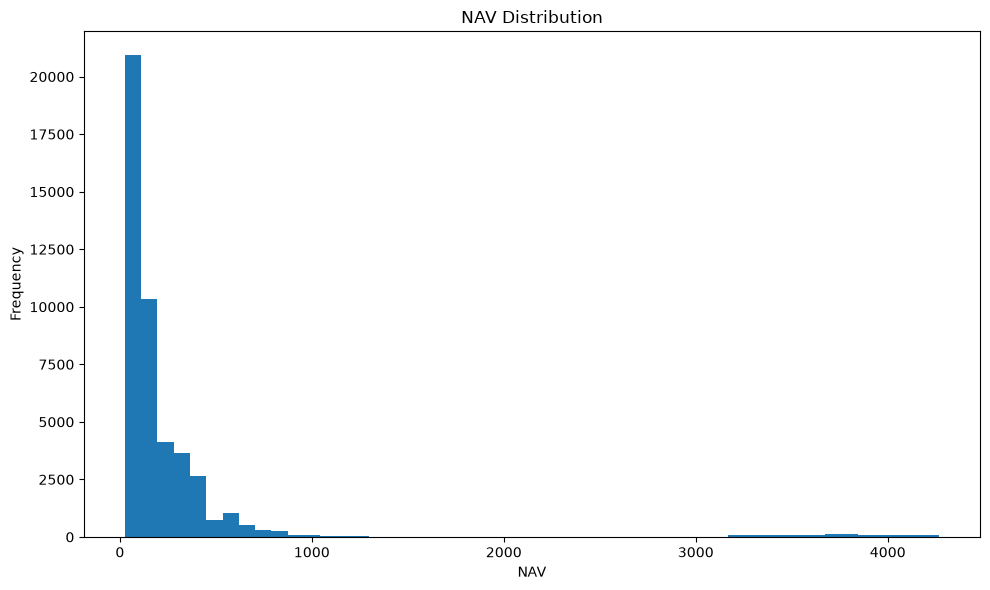

✅ NAV distribution chart saved successfully!


In [7]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create output folder if it doesn't exist
output_dir = Path("reports/charts")
output_dir.mkdir(parents=True, exist_ok=True)

# NAV Distribution
plt.figure(figsize=(10, 6))

plt.hist(nav["nav"], bins=50)

plt.title("NAV Distribution")
plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.tight_layout()

# Save chart
plt.savefig(output_dir / "nav_distribution.png", dpi=300)
plt.show()

print("✅ NAV distribution chart saved successfully!")

C:\Users\nisar\AppData\Local\Temp\ipykernel_388\3211560884.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(nav["nav"].dropna(), vert=False)


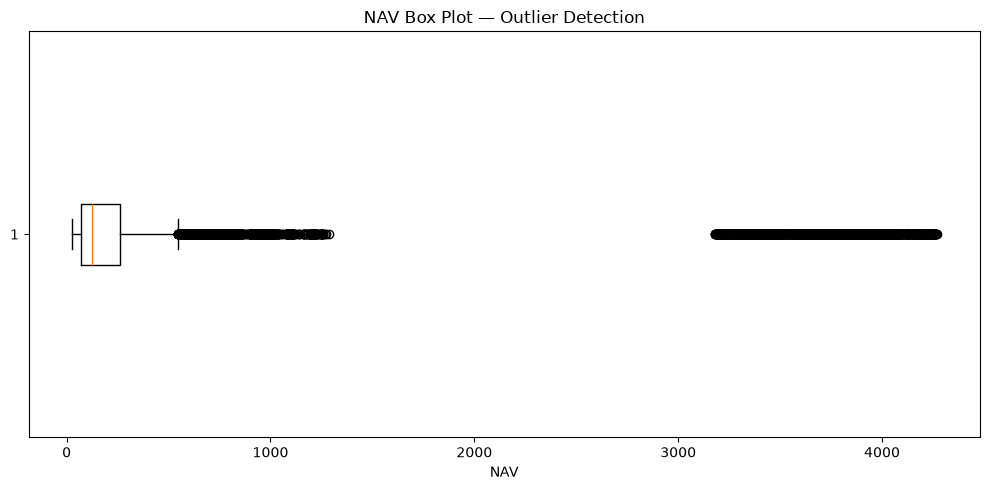

✅ NAV box plot saved successfully!


In [8]:
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("reports/charts")
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))

plt.boxplot(nav["nav"].dropna(), vert=False)

plt.title("NAV Box Plot — Outlier Detection")
plt.xlabel("NAV")

plt.tight_layout()
plt.savefig(output_dir / "nav_boxplot.png", dpi=300)
plt.show()

print("✅ NAV box plot saved successfully!")

Top 10 Funds by Average NAV:


amfi_code
120844    3705.876331
125497     797.454477
100016     566.191221
149322     439.176645
101206     435.975472
101208     358.390923
120841     355.078750
120507     334.083952
120505     283.999240
120506     274.320937
Name: nav, dtype: float64

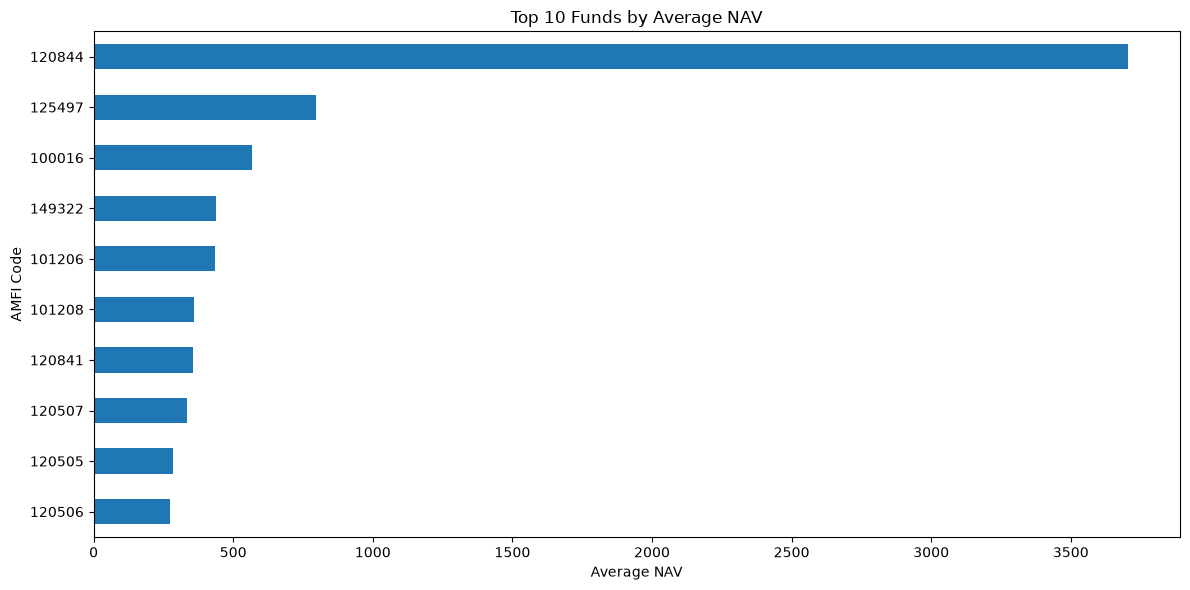

✅ Top 10 average NAV chart saved successfully!


In [9]:
# Average NAV by Fund

fund_nav = (
    nav.groupby("amfi_code")["nav"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Funds by Average NAV:")
display(fund_nav.head(10))

plt.figure(figsize=(12, 6))

fund_nav.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Funds by Average NAV")
plt.xlabel("Average NAV")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(output_dir / "top10_avg_nav.png", dpi=300)
plt.show()

print("✅ Top 10 average NAV chart saved successfully!")

NAV Dataset Columns:
['amfi_code', 'date', 'nav']

TOP 10 FUNDS BY AVERAGE NAV


,average_nav
amfi_code,
120844,3705.876331
125497,797.454477
100016,566.191221
149322,439.176645
101206,435.975472
101208,358.390923
120841,355.078750
120507,334.083952
120505,283.999240


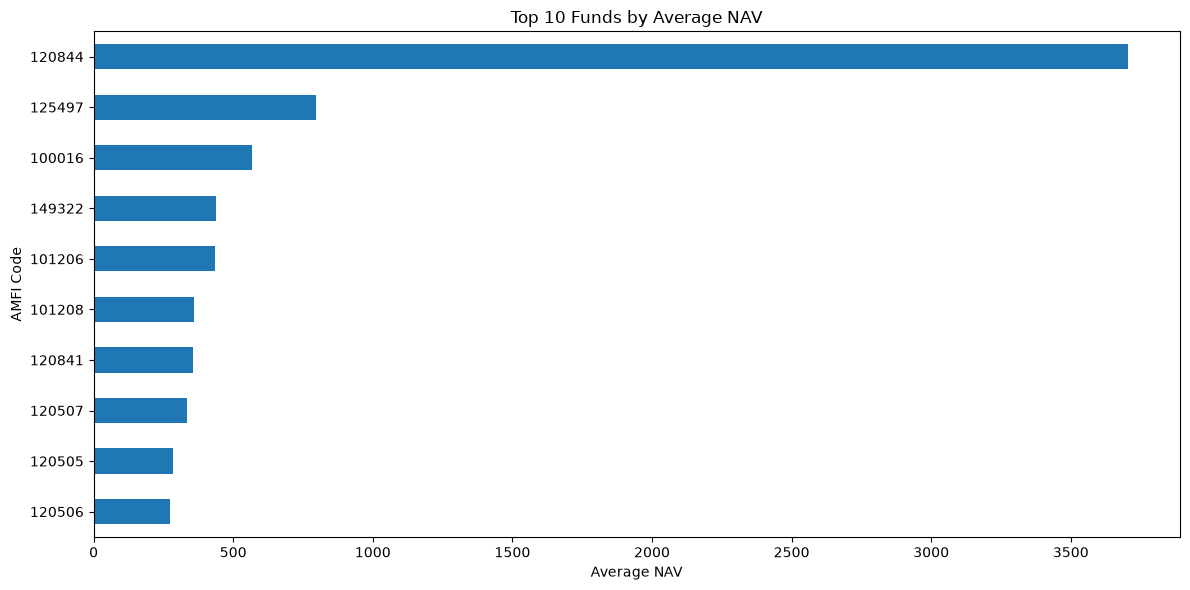


✅ Top 10 average NAV chart saved successfully!


In [11]:
# ============================================================
# EDA — TOP 10 FUNDS BY AVERAGE NAV
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

# Create output directory
output_dir = Path("reports/charts")
output_dir.mkdir(parents=True, exist_ok=True)

# Check available columns
print("NAV Dataset Columns:")
print(nav.columns.tolist())

# Calculate average NAV for each fund
fund_nav = (
    nav.groupby("amfi_code")["nav"]
    .mean()
    .sort_values(ascending=False)
)

# Display Top 10
print("\n" + "=" * 60)
print("TOP 10 FUNDS BY AVERAGE NAV")
print("=" * 60)

top10_avg_nav = fund_nav.head(10)

display(top10_avg_nav.to_frame(name="average_nav"))

# Plot
plt.figure(figsize=(12, 6))

top10_avg_nav.sort_values().plot(kind="barh")

plt.title("Top 10 Funds by Average NAV")
plt.xlabel("Average NAV")
plt.ylabel("AMFI Code")

plt.tight_layout()

# Save chart
plt.savefig(
    output_dir / "top10_avg_nav.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Top 10 average NAV chart saved successfully!")

AVERAGE NAV TREND OVER TIME

First 10 observations:


,average_nav
date,
2022-01-03,207.213793
2022-01-04,206.890585
2022-01-05,207.226548
2022-01-06,207.190405
2022-01-07,207.081100
2022-01-10,207.133505
2022-01-11,207.092298
2022-01-12,206.954320
2022-01-13,206.786692



Last 10 observations:


,average_nav
date,
2026-05-18,356.818015
2026-05-19,357.050300
2026-05-20,356.576550
2026-05-21,357.380825
2026-05-22,357.625308
2026-05-25,357.663928
2026-05-26,357.702880
2026-05-27,357.900877
2026-05-28,357.751768


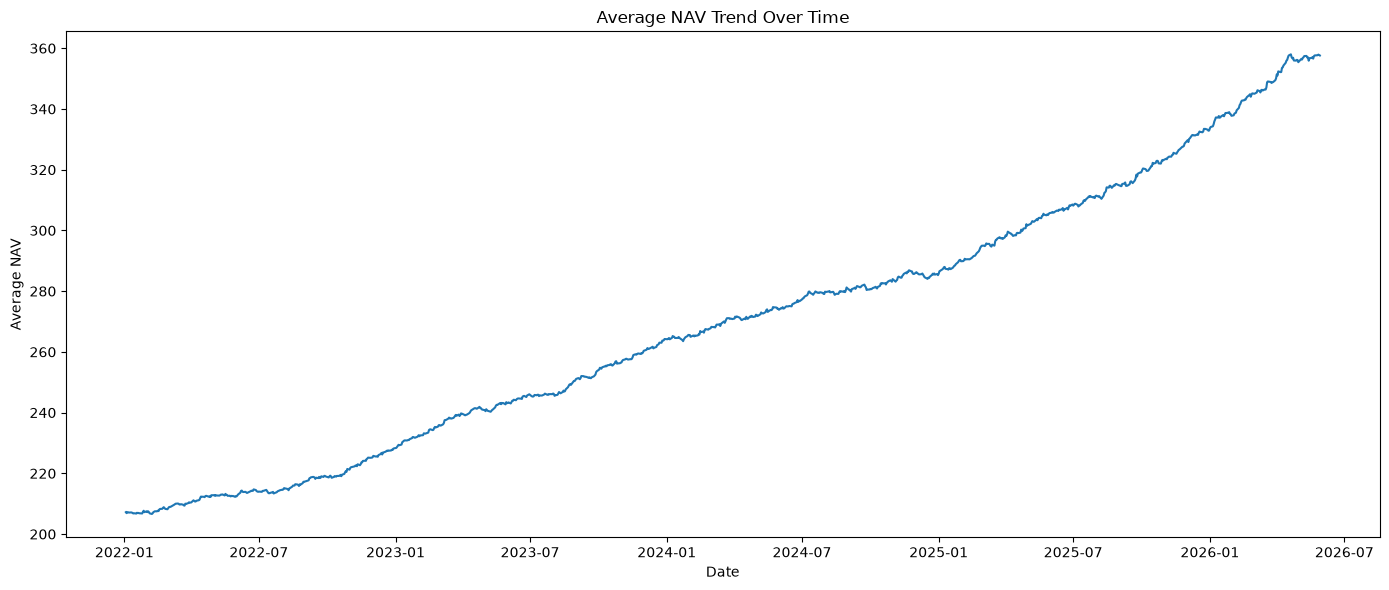

✅ Average NAV trend chart saved successfully!


In [12]:
# ============================================================
# EDA — AVERAGE NAV TREND OVER TIME
# ============================================================

# Calculate daily average NAV
daily_avg_nav = (
    nav.groupby("date")["nav"]
    .mean()
    .sort_index()
)

print("=" * 60)
print("AVERAGE NAV TREND OVER TIME")
print("=" * 60)

print("\nFirst 10 observations:")
display(daily_avg_nav.head(10).to_frame(name="average_nav"))

print("\nLast 10 observations:")
display(daily_avg_nav.tail(10).to_frame(name="average_nav"))

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    daily_avg_nav.index,
    daily_avg_nav.values
)

plt.title("Average NAV Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.tight_layout()

plt.savefig(
    output_dir / "average_nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Average NAV trend chart saved successfully!")

DAILY NAV RETURN ANALYSIS

Return Statistics:


,daily_return_pct
count,45960.000000
mean,0.063105
std,1.029041
min,-5.810201
25%,-0.504211
50%,0.034021
75%,0.632376
max,6.471309



Number of return observations: 45960


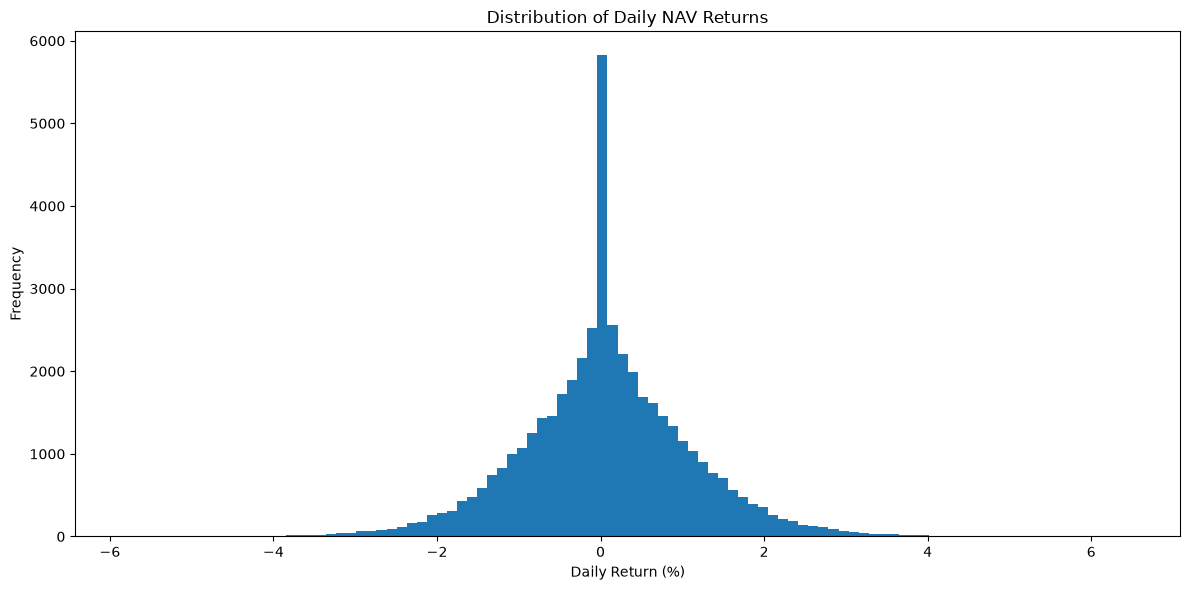

✅ Daily NAV return distribution saved successfully!


In [13]:
# ============================================================
# EDA — DAILY NAV RETURNS
# ============================================================

# Sort data correctly
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Calculate daily percentage return for each fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change() * 100
)

# Remove first observation of each fund
returns = nav["daily_return"].dropna()

print("=" * 60)
print("DAILY NAV RETURN ANALYSIS")
print("=" * 60)

print("\nReturn Statistics:")
display(returns.describe().to_frame(name="daily_return_pct"))

print("\nNumber of return observations:", len(returns))

# Distribution plot
plt.figure(figsize=(12, 6))

plt.hist(returns, bins=100)

plt.title("Distribution of Daily NAV Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    output_dir / "daily_nav_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Daily NAV return distribution saved successfully!")

FUND-WISE DAILY RETURN VOLATILITY

Top 10 Most Volatile Funds:


,daily_volatility_pct
amfi_code,
101207,1.625079
118634,1.590066
119598,1.583708
119095,1.579046
119599,1.571710
149324,1.564786
119094,1.222533
120505,1.215216
100033,1.192901


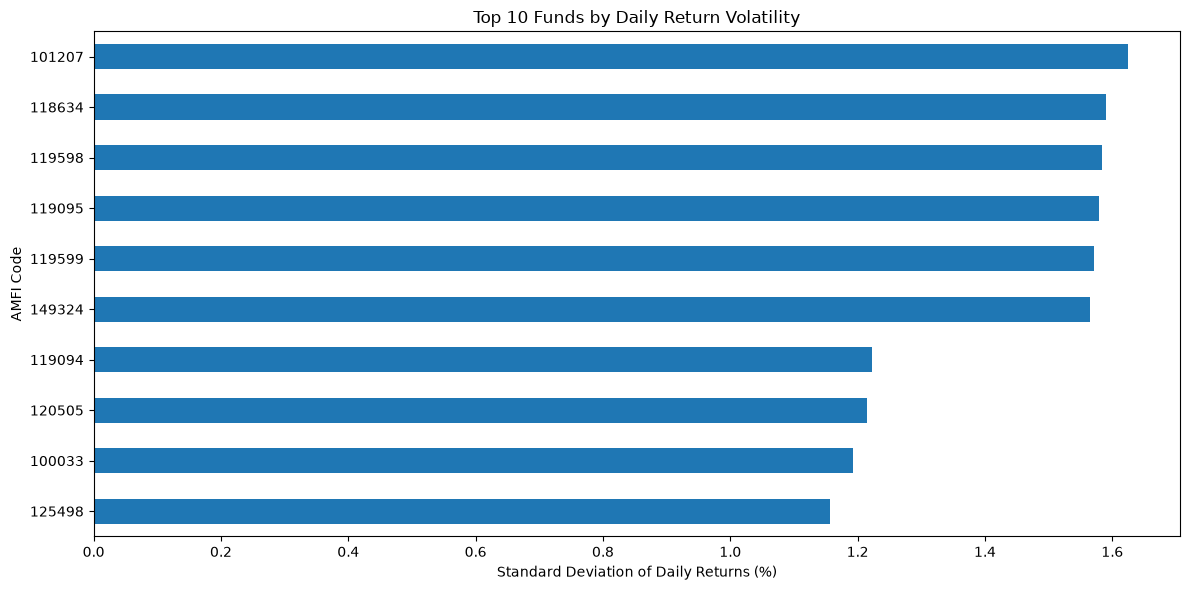

✅ Fund volatility analysis saved successfully!


In [14]:
# ============================================================
# EDA — DAILY RETURN VOLATILITY BY FUND
# ============================================================

# Calculate standard deviation of daily returns for each fund
fund_volatility = (
    nav.groupby("amfi_code")["daily_return"]
    .std()
    .sort_values(ascending=False)
)

print("=" * 60)
print("FUND-WISE DAILY RETURN VOLATILITY")
print("=" * 60)

print("\nTop 10 Most Volatile Funds:")
display(
    fund_volatility.head(10)
    .to_frame(name="daily_volatility_pct")
)

# Plot Top 10
plt.figure(figsize=(12, 6))

fund_volatility.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Funds by Daily Return Volatility")
plt.xlabel("Standard Deviation of Daily Returns (%)")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(
    output_dir / "top10_fund_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Fund volatility analysis saved successfully!")

MONTHLY NAV RETURN ANALYSIS

Monthly Return Statistics:


,monthly_return_pct
count,2120.000000
mean,1.305829
std,4.815788
min,-18.285793
25%,-1.170724
50%,0.772484
75%,3.822318
max,25.710594



Top 10 Funds by Average Monthly Return:


,average_monthly_return_pct
amfi_code,
119598,2.667967
148569,2.429776
120843,2.383708
100033,2.364583
120505,2.351672
149323,2.309845
149324,2.298887
119094,2.293835
148567,1.984605


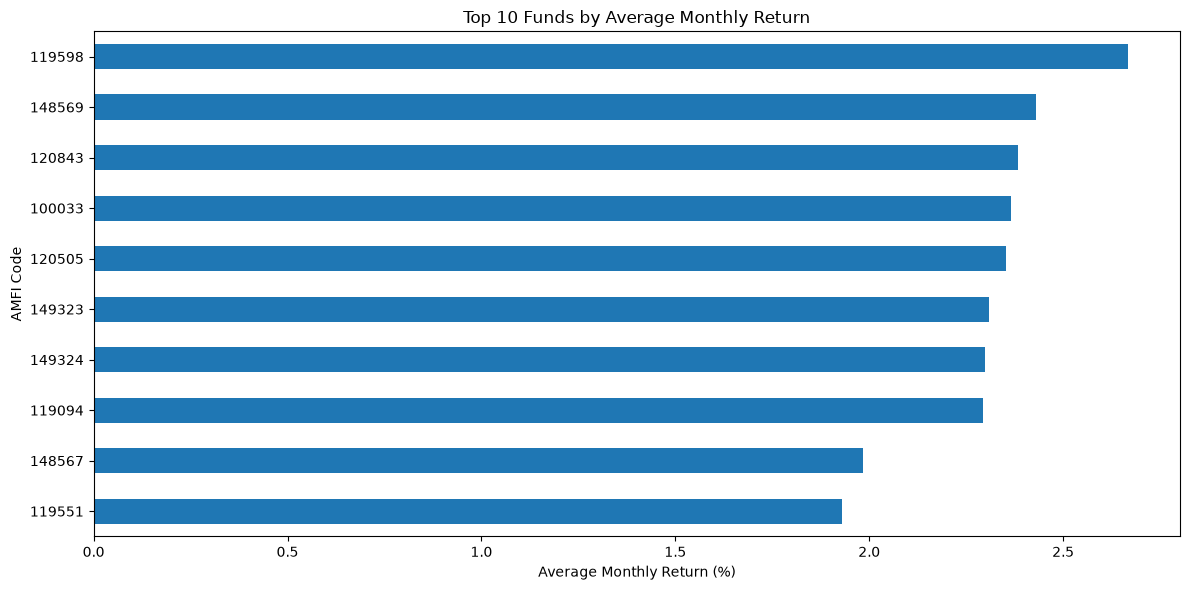

✅ Monthly return analysis saved successfully!


In [15]:
# ============================================================
# EDA — MONTHLY NAV RETURNS
# ============================================================

# Make sure date is datetime
nav["date"] = pd.to_datetime(nav["date"])

# Create month column
nav["month"] = nav["date"].dt.to_period("M")

# Calculate monthly return for each fund
monthly_nav = (
    nav.sort_values(["amfi_code", "date"])
       .groupby(["amfi_code", "month"])["nav"]
       .agg(["first", "last"])
       .reset_index()
)

monthly_nav["monthly_return"] = (
    (monthly_nav["last"] - monthly_nav["first"])
    / monthly_nav["first"]
) * 100

print("=" * 60)
print("MONTHLY NAV RETURN ANALYSIS")
print("=" * 60)

print("\nMonthly Return Statistics:")
display(
    monthly_nav["monthly_return"]
    .describe()
    .to_frame(name="monthly_return_pct")
)

# Average monthly return by fund
fund_monthly_return = (
    monthly_nav.groupby("amfi_code")["monthly_return"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 10 Funds by Average Monthly Return:")
display(
    fund_monthly_return.head(10)
    .to_frame(name="average_monthly_return_pct")
)

# Plot
plt.figure(figsize=(12, 6))

fund_monthly_return.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Funds by Average Monthly Return")
plt.xlabel("Average Monthly Return (%)")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(
    output_dir / "top10_monthly_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Monthly return analysis saved successfully!")

In [21]:
# ============================================================
# FIND AND LOAD AUM DATASET
# ============================================================

from pathlib import Path
import pandas as pd

# Check current location
print("Current working directory:")
print(Path.cwd())

# Search project folders for AUM CSV files
project_dir = Path("..")

aum_files = list(project_dir.rglob("*aum*.csv"))

print("\nAUM CSV files found:")

if len(aum_files) == 0:
    print("❌ No AUM CSV found.")
else:
    for i, file in enumerate(aum_files):
        print(f"{i}: {file}")

# Load if found
if len(aum_files) > 0:
    aum_path = aum_files[0]
    aum = pd.read_csv(aum_path)

    print("\n" + "=" * 60)
    print("AUM DATASET LOADED")
    print("=" * 60)

    print("File:", aum_path)
    print("Shape:", aum.shape)
    print("Columns:", aum.columns.tolist())

    display(aum.head())

Current working directory:
c:\Users\nisar\OneDrive\Desktop\Bluestock-Internship\Bluestock-Internship\notebooks

AUM CSV files found:
0: ..\data\raw\03_aum_by_fund_house.csv

AUM DATASET LOADED
File: ..\data\raw\03_aum_by_fund_house.csv
Shape: (90, 5)
Columns: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


AUM GROWTH BY FUND HOUSE

AUM Summary:


,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,5.63
1,2022,Axis Mutual Fund,4.90
2,2022,DSP Mutual Fund,2.22
3,2022,HDFC Mutual Fund,8.80
4,2022,ICICI Prudential MF,9.53
5,2022,Kotak Mahindra MF,5.42
6,2022,Mirae Asset MF,2.13
7,2022,Nippon India MF,5.48
8,2022,SBI Mutual Fund,12.35
9,2022,UTI Mutual Fund,4.62


<Figure size 1400x700 with 0 Axes>

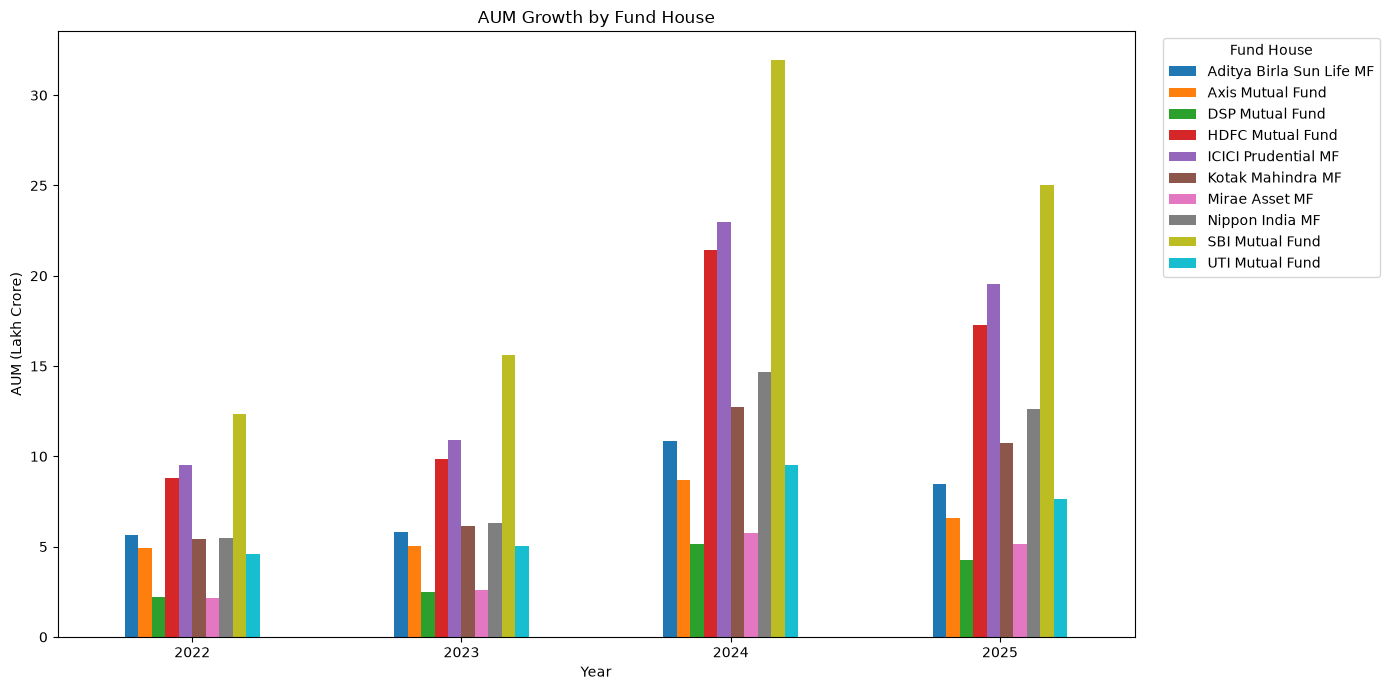

✅ AUM growth by fund house chart saved successfully!


In [22]:
# ============================================================
# EDA — AUM GROWTH BY FUND HOUSE
# ============================================================

# Convert date
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

print("=" * 60)
print("AUM GROWTH BY FUND HOUSE")
print("=" * 60)

# Aggregate AUM by year and fund house
aum_by_house = (
    aum.groupby(["year", "fund_house"])["aum_lakh_crore"]
    .sum()
    .reset_index()
)

print("\nAUM Summary:")
display(aum_by_house)

# Pivot for chart
aum_pivot = aum_by_house.pivot(
    index="year",
    columns="fund_house",
    values="aum_lakh_crore"
)

# Plot
plt.figure(figsize=(14, 7))

aum_pivot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save
plt.savefig(
    output_dir / "aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ AUM growth by fund house chart saved successfully!")

In [23]:
# ============================================================
# EDA — SIP INFLOW DATASET
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Find SIP dataset
project_dir = Path("..")

sip_files = list(project_dir.rglob("*sip*inflow*.csv"))

print("SIP CSV files found:")

for i, file in enumerate(sip_files):
    print(f"{i}: {file}")

# Load dataset
sip_path = sip_files[0]

sip = pd.read_csv(sip_path)

print("\n" + "=" * 60)
print("SIP INFLOW DATASET")
print("=" * 60)

print("File:", sip_path)
print("Shape:", sip.shape)
print("Columns:", sip.columns.tolist())

display(sip.head())

SIP CSV files found:
0: ..\data\raw\04_monthly_sip_inflows.csv

SIP INFLOW DATASET
File: ..\data\raw\04_monthly_sip_inflows.csv
Shape: (48, 6)
Columns: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


SIP INFLOW TREND ANALYSIS

Date range:
2022-01-01 00:00:00 to 2025-12-01 00:00:00

Total months: 48

SIP Inflow Statistics:


count       48.000000
mean     19577.520833
std       6354.329621
min      11438.000000
25%      13658.500000
50%      18224.000000
75%      25944.250000
max      31002.000000
Name: sip_inflow_crore, dtype: float64


Highest SIP Inflow:
Month: 2025-12
SIP Inflow: 31002 Crore


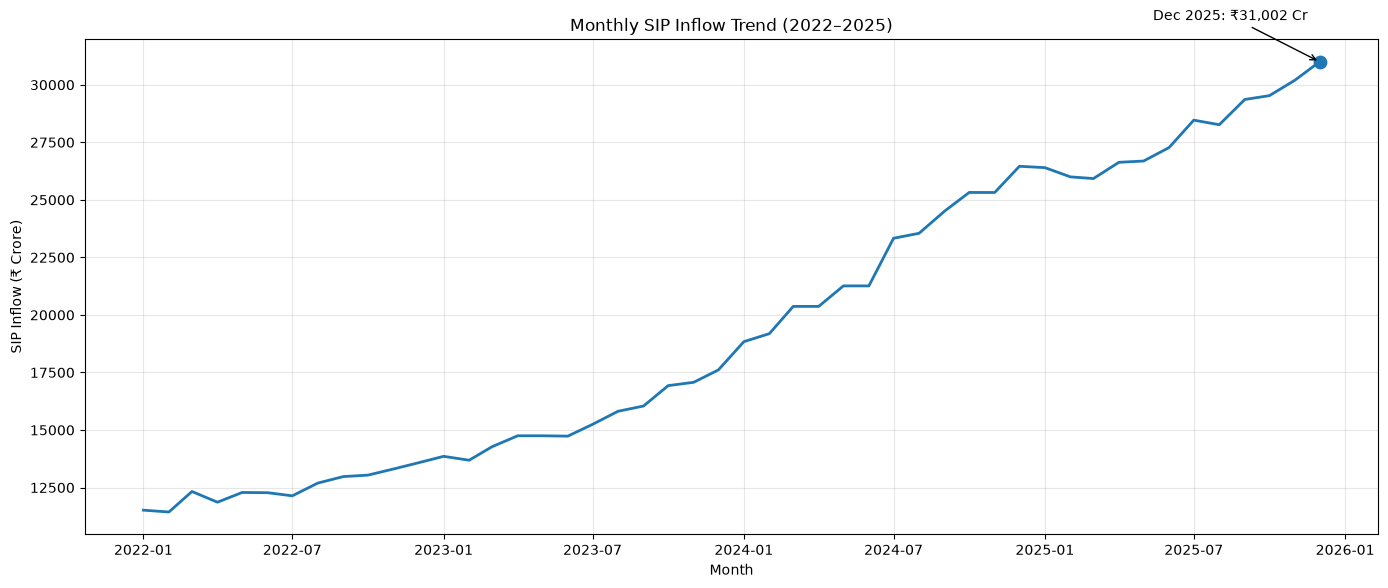


✅ SIP inflow trend chart saved successfully!


In [24]:
# ============================================================
# EDA — SIP INFLOW TREND ANALYSIS
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Sort by month
sip = sip.sort_values("month").reset_index(drop=True)

print("=" * 60)
print("SIP INFLOW TREND ANALYSIS")
print("=" * 60)

print("\nDate range:")
print(sip["month"].min(), "to", sip["month"].max())

print("\nTotal months:", len(sip))

print("\nSIP Inflow Statistics:")
display(sip["sip_inflow_crore"].describe())

# ------------------------------------------------------------
# Find maximum SIP inflow
# ------------------------------------------------------------

max_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

print("\nHighest SIP Inflow:")
print("Month:", max_sip["month"].strftime("%Y-%m"))
print("SIP Inflow:", max_sip["sip_inflow_crore"], "Crore")

# ------------------------------------------------------------
# Plot SIP inflow trend
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    linewidth=2
)

# Mark Dec 2025 milestone
milestone = sip[sip["month"] == pd.Timestamp("2025-12-01")]

if not milestone.empty:
    x = milestone["month"].iloc[0]
    y = milestone["sip_inflow_crore"].iloc[0]

    plt.scatter(x, y, s=80)

    plt.annotate(
        f"Dec 2025: ₹{y:,.0f} Cr",
        xy=(x, y),
        xytext=(-120, 30),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->")
    )

plt.title("Monthly SIP Inflow Trend (2022–2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.grid(True, alpha=0.3)

plt.tight_layout()

# ------------------------------------------------------------
# Save chart
# ------------------------------------------------------------

output_dir = Path("../reports/charts")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "sip_inflow_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ SIP inflow trend chart saved successfully!")

Category inflow CSV files found:
0: ..\data\raw\05_category_inflows.csv

CATEGORY INFLOW DATASET
File: ..\data\raw\05_category_inflows.csv
Shape: (144, 3)
Columns: ['month', 'category', 'net_inflow_crore']


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0



Detected columns:
Category: category
Month: month
Inflow: net_inflow_crore

Cleaned Shape: (144, 3)

CATEGORY-WISE INFLOW PIVOT TABLE


month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


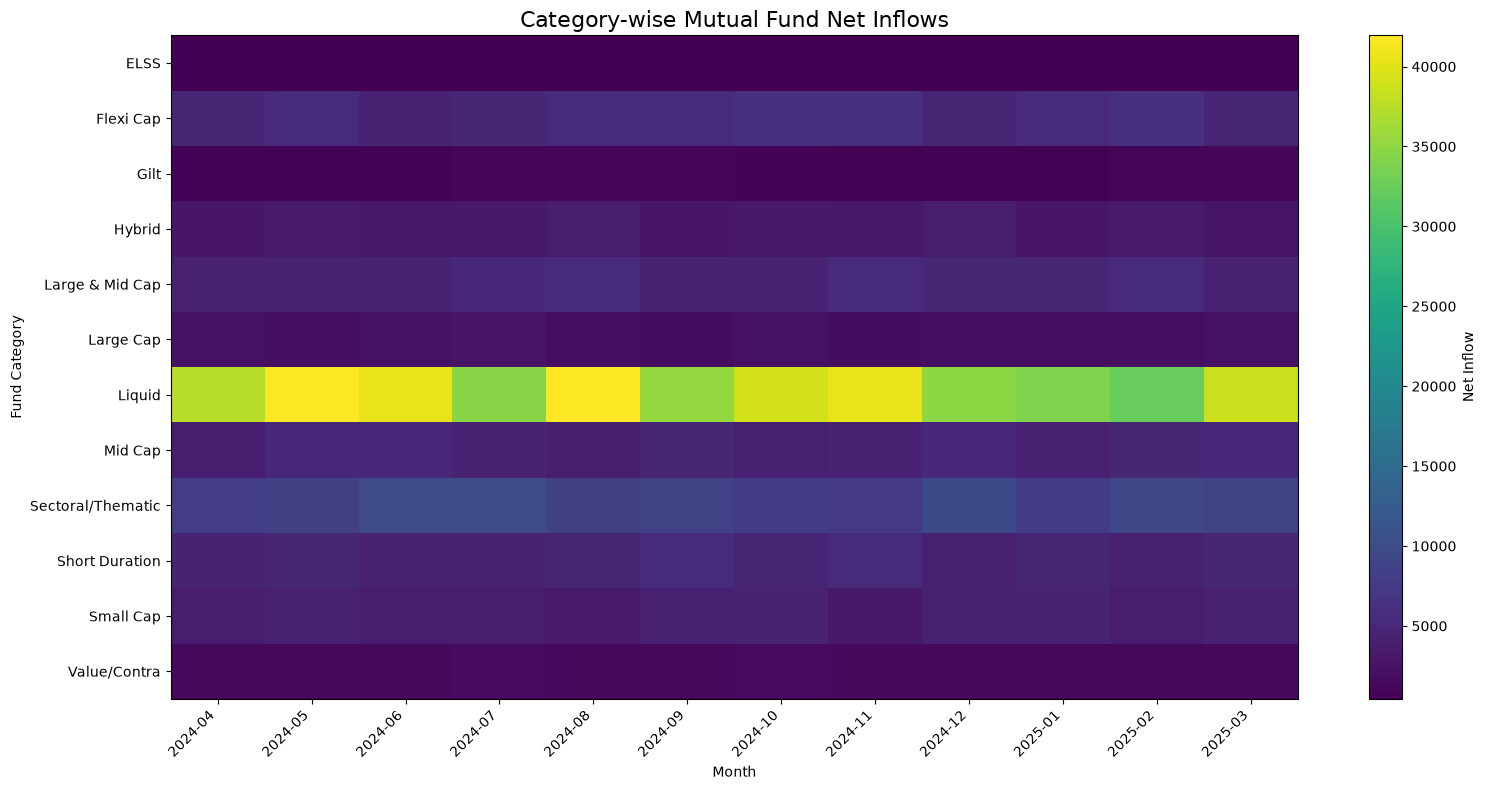


✅ Category-wise inflow heatmap saved successfully!
Saved to: ..\reports\charts\category_inflow_heatmap.png


In [26]:
# ============================================================
# EDA — CATEGORY-WISE INFLOW HEATMAP
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Find category inflow dataset
# ------------------------------------------------------------

project_dir = Path("..")

category_files = list(
    project_dir.rglob("*category*inflow*.csv")
)

print("Category inflow CSV files found:")

for i, file in enumerate(category_files):
    print(f"{i}: {file}")

if not category_files:
    raise FileNotFoundError(
        "❌ Category inflow CSV not found."
    )

category_path = category_files[0]

# Load dataset
category = pd.read_csv(category_path)

print("\n" + "=" * 60)
print("CATEGORY INFLOW DATASET")
print("=" * 60)

print("File:", category_path)
print("Shape:", category.shape)
print("Columns:", category.columns.tolist())

display(category.head())


# ------------------------------------------------------------
# 2. Detect columns
# ------------------------------------------------------------

category_col = None
month_col = None
inflow_col = None

for col in category.columns:

    name = col.lower()

    if category_col is None:
        if "category" in name or "sub_category" in name:
            category_col = col

    if month_col is None:
        if "month" in name or "period" in name:
            month_col = col

    if inflow_col is None:
        if "inflow" in name or "amount" in name:
            inflow_col = col


print("\nDetected columns:")
print("Category:", category_col)
print("Month:", month_col)
print("Inflow:", inflow_col)


# ------------------------------------------------------------
# 3. If month column is not available
# ------------------------------------------------------------

if month_col is None:

    # Check available columns
    print("\n⚠️ Month column was not detected.")
    print("Available columns:", category.columns.tolist())

    raise ValueError(
        "Please check the dataset columns above."
    )


# ------------------------------------------------------------
# 4. Validate
# ------------------------------------------------------------

if category_col is None:
    raise ValueError("❌ Category column not found.")

if inflow_col is None:
    raise ValueError("❌ Inflow column not found.")


# ------------------------------------------------------------
# 5. Clean data
# ------------------------------------------------------------

category[month_col] = category[month_col].astype(str)

category[inflow_col] = pd.to_numeric(
    category[inflow_col],
    errors="coerce"
)

category = category.dropna(
    subset=[
        category_col,
        month_col,
        inflow_col
    ]
)

print("\nCleaned Shape:", category.shape)


# ------------------------------------------------------------
# 6. Create pivot table
# ------------------------------------------------------------

heatmap_data = category.pivot_table(
    index=category_col,
    columns=month_col,
    values=inflow_col,
    aggfunc="sum"
)

print("\n" + "=" * 60)
print("CATEGORY-WISE INFLOW PIVOT TABLE")
print("=" * 60)

display(heatmap_data)


# ------------------------------------------------------------
# 7. Create heatmap using Matplotlib
# ------------------------------------------------------------

plt.figure(figsize=(16, 8))

plt.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Net Inflow"
)

plt.title(
    "Category-wise Mutual Fund Net Inflows",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Fund Category")


# X-axis labels
plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

# Y-axis labels
plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.tight_layout()


# ------------------------------------------------------------
# 8. Save chart
# ------------------------------------------------------------

output_dir = Path("../reports/charts")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir /
    "category_inflow_heatmap.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\n✅ Category-wise inflow heatmap saved successfully!"
)

print("Saved to:", output_path)

In [28]:
# ============================================================
# EDA — TASK 5: INVESTOR DEMOGRAPHICS
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Find investor transaction dataset
# ------------------------------------------------------------

project_dir = Path("..")

investor_files = list(
    project_dir.rglob("*investor*transaction*.csv")
)

print("Investor transaction files found:")

for i, file in enumerate(investor_files):
    print(f"{i}: {file}")

if not investor_files:
    raise FileNotFoundError(
        "❌ Investor transaction dataset not found."
    )

investor_path = investor_files[0]

# Load dataset
investor = pd.read_csv(investor_path)

print("\n" + "=" * 60)
print("INVESTOR TRANSACTION DATASET")
print("=" * 60)

print("File:", investor_path)
print("Shape:", investor.shape)
print("Columns:", investor.columns.tolist())

display(investor.head())


# ------------------------------------------------------------
# 2. Detect important columns
# ------------------------------------------------------------

age_col = None
sip_col = None

for col in investor.columns:

    name = col.lower()

    if age_col is None:
        if "age_group" in name or "agegroup" in name:
            age_col = col
        elif name == "age":
            age_col = col

    if sip_col is None:
        if "sip" in name and (
            "amount" in name or
            "amt" in name
        ):
            sip_col = col


print("\nDetected columns:")
print("Age column:", age_col)
print("SIP amount column:", sip_col)


# ------------------------------------------------------------
# 3. Display columns if detection fails
# ------------------------------------------------------------

if age_col is None or sip_col is None:

    print("\n⚠️ Please check these columns:")
    print(investor.columns.tolist())

    raise ValueError(
        "Could not automatically identify age/SIP columns."
    )


# ------------------------------------------------------------
# 4. Clean data
# ------------------------------------------------------------

investor[sip_col] = pd.to_numeric(
    investor[sip_col],
    errors="coerce"
)

investor = investor.dropna(
    subset=[age_col, sip_col]
)

print("\nCleaned Shape:", investor.shape)


# ============================================================
# CHART 1 — AGE GROUP DISTRIBUTION
# ============================================================

age_counts = investor[age_col].value_counts()

print("\n" + "=" * 60)
print("AGE GROUP DISTRIBUTION")
print("=" * 60)

display(age_counts)


plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Age Group Distribution",
    fontsize=15
)

plt.tight_layout()

output_dir = Path("../reports/charts")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    output_dir / "investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Age distribution chart saved successfully!"
)


# ============================================================
# CHART 2 — SIP AMOUNT BY AGE GROUP
# ============================================================

age_groups = []

for group in investor[age_col].dropna().unique():
    values = investor.loc[
        investor[age_col] == group,
        sip_col
    ].dropna()

    age_groups.append(values)


plt.figure(figsize=(12, 7))

plt.boxplot(
    age_groups,
    labels=[
        str(group)
        for group in investor[age_col].dropna().unique()
    ]
)

plt.title(
    "SIP Amount Distribution by Age Group",
    fontsize=15
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount")

plt.tight_layout()

plt.savefig(
    output_dir / "sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ SIP amount by age group chart saved successfully!"
)

print("\n🎉 TASK 5 — INVESTOR DEMOGRAPHICS COMPLETED!")
print(investor.columns.tolist())

Investor transaction files found:
0: ..\data\processed\cleaned_investor_transactions.csv
1: ..\data\raw\08_investor_transactions.csv

INVESTOR TRANSACTION DATASET
File: ..\data\processed\cleaned_investor_transactions.csv
Shape: (32778, 13)
Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending



Detected columns:
Age column: age_group
SIP amount column: None

⚠️ Please check these columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


ValueError: Could not automatically identify age/SIP columns.

In [29]:
print("ACTUAL INVESTOR COLUMNS:")
print(investor.columns.tolist())

ACTUAL INVESTOR COLUMNS:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


INVESTOR DEMOGRAPHICS ANALYSIS
Dataset shape: (32778, 13)

AGE GROUP DISTRIBUTION
----------------------------------------
age_group
26-35    2033
36-45    1237
18-25     753
46-55     589
56+       388
Name: count, dtype: int64


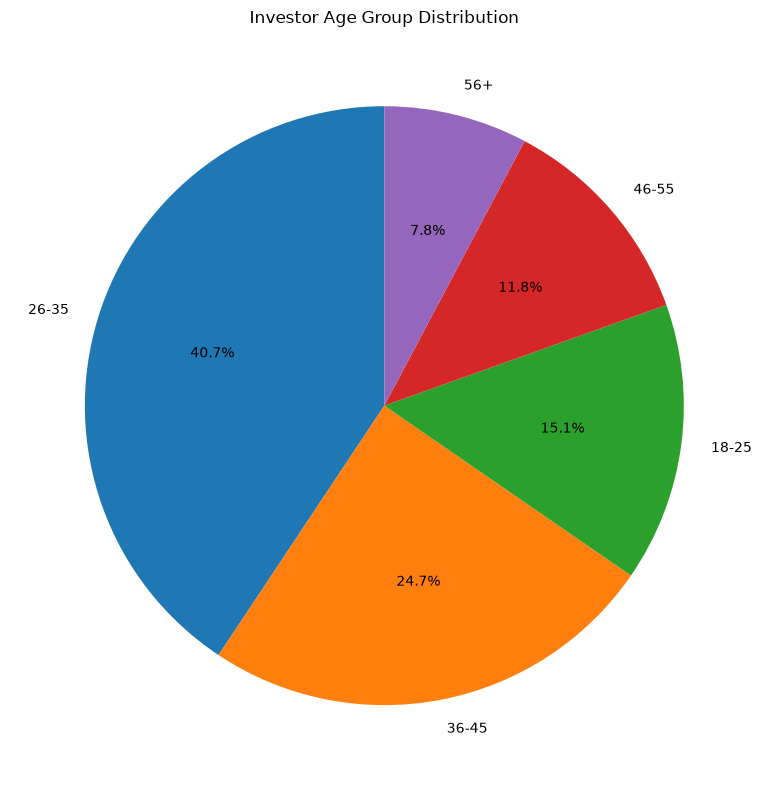

✅ Age distribution chart saved successfully!

SIP TRANSACTIONS
----------------------------------------
Number of SIP transactions: 19716

Average SIP amount by age group:


,count,mean,median
age_group,,,
18-25,2949,10953.073245,5020.0
26-35,8063,10986.895696,5070.0
36-45,4926,10885.758628,5250.0
46-55,2300,11136.763478,5136.0
56+,1478,11574.922192,5420.5


TypeError: boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

<Figure size 1000x700 with 0 Axes>

In [30]:
# ============================================================
# TASK 5 — INVESTOR DEMOGRAPHICS
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Use the already loaded investor dataset
# ------------------------------------------------------------

print("=" * 60)
print("INVESTOR DEMOGRAPHICS ANALYSIS")
print("=" * 60)

print("Dataset shape:", investor.shape)

# ============================================================
# 1. AGE GROUP DISTRIBUTION
# ============================================================

# One record per investor to avoid counting the same investor
# multiple times
investor_demo = (
    investor[
        ["investor_id", "age_group", "gender"]
    ]
    .drop_duplicates("investor_id")
    .dropna(subset=["age_group"])
)

age_distribution = investor_demo["age_group"].value_counts()

print("\nAGE GROUP DISTRIBUTION")
print("-" * 40)
print(age_distribution)

# ------------------------------------------------------------
# Pie chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.pie(
    age_distribution.values,
    labels=age_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.tight_layout()

output_dir = Path("../reports/charts")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Age distribution chart saved successfully!")


# ============================================================
# 2. SIP AMOUNT BY AGE GROUP
# ============================================================

# Select only SIP transactions
sip_data = investor[
    investor["transaction_type"].astype(str).str.upper() == "SIP"
].copy()

# Convert amount to numeric
sip_data["amount_inr"] = pd.to_numeric(
    sip_data["amount_inr"],
    errors="coerce"
)

# Remove missing values
sip_data = sip_data.dropna(
    subset=["age_group", "amount_inr"]
)

print("\nSIP TRANSACTIONS")
print("-" * 40)
print("Number of SIP transactions:", len(sip_data))

print("\nAverage SIP amount by age group:")

sip_summary = (
    sip_data
    .groupby("age_group")["amount_inr"]
    .agg(["count", "mean", "median"])
    .sort_index()
)

display(sip_summary)


# ------------------------------------------------------------
# Box plot
# ------------------------------------------------------------

age_order = sorted(
    sip_data["age_group"].unique()
)

box_data = [
    sip_data.loc[
        sip_data["age_group"] == age,
        "amount_inr"
    ]
    for age in age_order
]

plt.figure(figsize=(10, 7))

plt.boxplot(
    box_data,
    labels=age_order
)

plt.title(
    "SIP Amount Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")

plt.tight_layout()

plt.savefig(
    output_dir / "sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SIP amount by age group chart saved successfully!")


# ============================================================
# TASK 5 COMPLETED
# ============================================================

print("\n" + "=" * 60)
print("✅ TASK 5 — INVESTOR DEMOGRAPHICS COMPLETED!")
print("=" * 60)

print("Charts created:")
print("1. investor_age_distribution.png")
print("2. sip_amount_by_age_group.png")

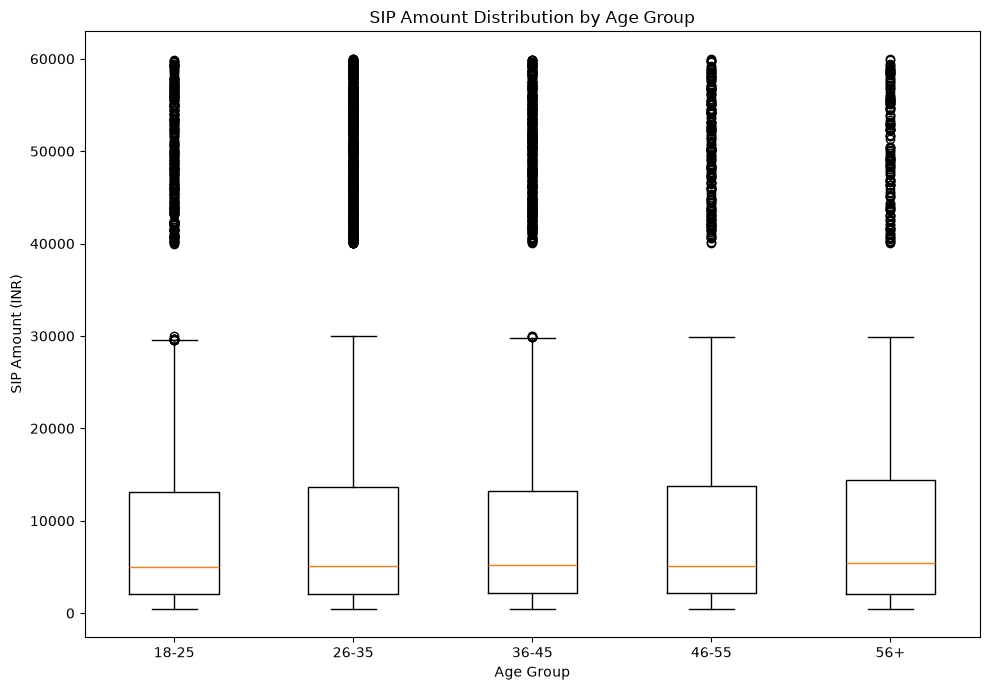

✅ SIP amount by age group chart saved successfully!
✅ TASK 5 — INVESTOR DEMOGRAPHICS COMPLETED!


In [31]:
# ============================================================
# FIX — SIP AMOUNT BOX PLOT
# ============================================================

plt.figure(figsize=(10, 7))

plt.boxplot(
    box_data,
    tick_labels=age_order
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")

plt.tight_layout()

plt.savefig(
    output_dir / "sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SIP amount by age group chart saved successfully!")
print("✅ TASK 5 — INVESTOR DEMOGRAPHICS COMPLETED!")

GEOGRAPHIC DISTRIBUTION ANALYSIS
SIP records: 19716

SIP AMOUNT BY STATE


state
Maharashtra       16445629
Rajasthan         16544233
Delhi             17113608
West Bengal       17495769
Uttar Pradesh     17534858
Karnataka         17696903
Haryana           18176696
Gujarat           18378904
Tamil Nadu        18404368
Telangana         18620216
Punjab            20140064
Madhya Pradesh    20682243
Name: amount_inr, dtype: int64

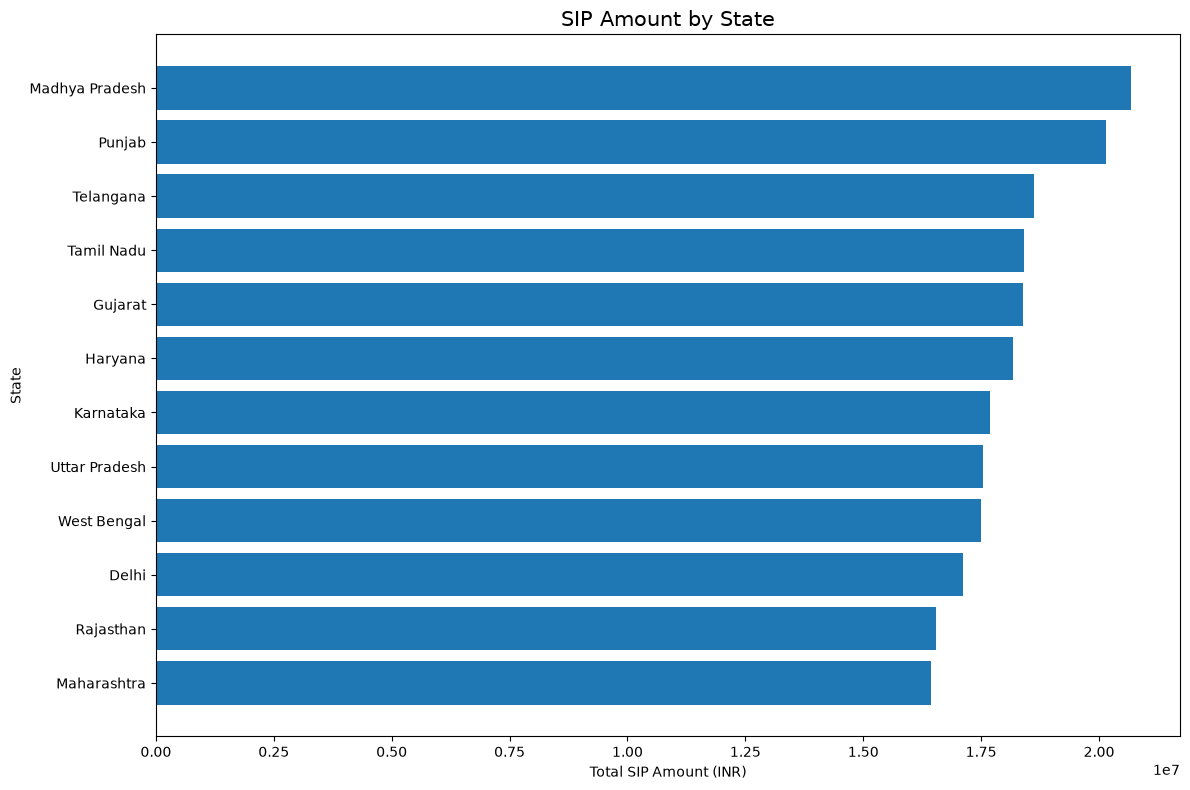

✅ SIP amount by state chart saved successfully!

CITY TIER DISTRIBUTION


city_tier
T30    13123
B30     6593
Name: count, dtype: int64

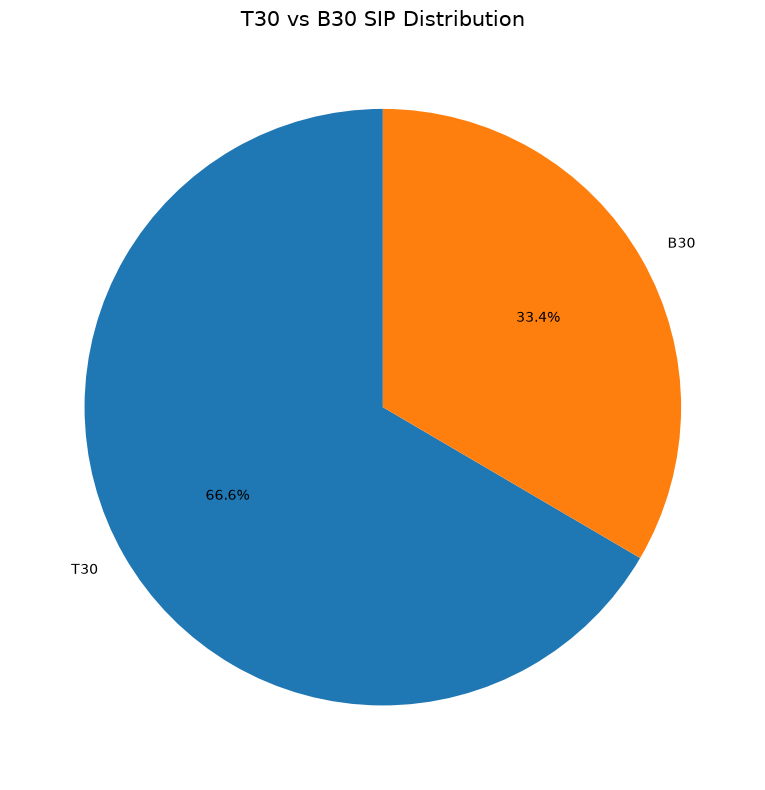

✅ T30 vs B30 chart saved successfully!

✅ TASK 6 — GEOGRAPHIC DISTRIBUTION COMPLETED!
Charts created:
1. sip_amount_by_state.png
2. t30_b30_distribution.png


In [32]:
# ============================================================
# TASK 6 — GEOGRAPHIC DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

print("=" * 60)
print("GEOGRAPHIC DISTRIBUTION ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Select SIP transactions
# ------------------------------------------------------------

sip_geo = investor[
    investor["transaction_type"].astype(str).str.upper() == "SIP"
].copy()

sip_geo["amount_inr"] = pd.to_numeric(
    sip_geo["amount_inr"],
    errors="coerce"
)

sip_geo = sip_geo.dropna(
    subset=["state", "city_tier", "amount_inr"]
)

print("SIP records:", len(sip_geo))


# ============================================================
# CHART 1 — SIP AMOUNT BY STATE
# ============================================================

state_sip = (
    sip_geo
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

print("\n" + "=" * 60)
print("SIP AMOUNT BY STATE")
print("=" * 60)

display(state_sip)


plt.figure(figsize=(12, 8))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title(
    "SIP Amount by State",
    fontsize=15
)

plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

output_dir = Path("../reports/charts")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    output_dir / "sip_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SIP amount by state chart saved successfully!")


# ============================================================
# CHART 2 — T30 vs B30 DISTRIBUTION
# ============================================================

tier_distribution = (
    sip_geo["city_tier"]
    .value_counts()
)

print("\n" + "=" * 60)
print("CITY TIER DISTRIBUTION")
print("=" * 60)

display(tier_distribution)


plt.figure(figsize=(8, 8))

plt.pie(
    tier_distribution.values,
    labels=tier_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 SIP Distribution",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    output_dir / "t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ T30 vs B30 chart saved successfully!")


# ============================================================
# TASK 6 COMPLETED
# ============================================================

print("\n" + "=" * 60)
print("✅ TASK 6 — GEOGRAPHIC DISTRIBUTION COMPLETED!")
print("=" * 60)

print("Charts created:")
print("1. sip_amount_by_state.png")
print("2. t30_b30_distribution.png")

FOLIO COUNT GROWTH ANALYSIS
Folio files found:
..\data\raw\06_industry_folio_count.csv
..\data\raw\09_portfolio_holdings.csv

FOLIO DATASET LOADED
File: ..\data\raw\06_industry_folio_count.csv
Shape: (21, 6)
Columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48



Date column: month
Folio column: total_folios_crore

FOLIO COUNT DATA


,month,total_folios_crore
0,2022-01-01,13.26
1,2022-04-01,13.91
2,2022-07-01,13.85
3,2022-10-01,14.12
4,2023-01-01,14.81
5,2023-04-01,15.54
6,2023-07-01,16.28
7,2023-10-01,16.72
8,2024-01-01,17.78
9,2024-04-01,18.85



Last observations:


,month,total_folios_crore
11,2024-10-01,21.62
12,2024-12-01,22.89
13,2025-01-01,23.10
14,2025-03-01,23.45
15,2025-04-01,23.89
16,2025-07-01,24.57
17,2025-08-01,24.89
18,2025-09-01,25.19
19,2025-10-01,25.60
20,2025-12-01,26.12


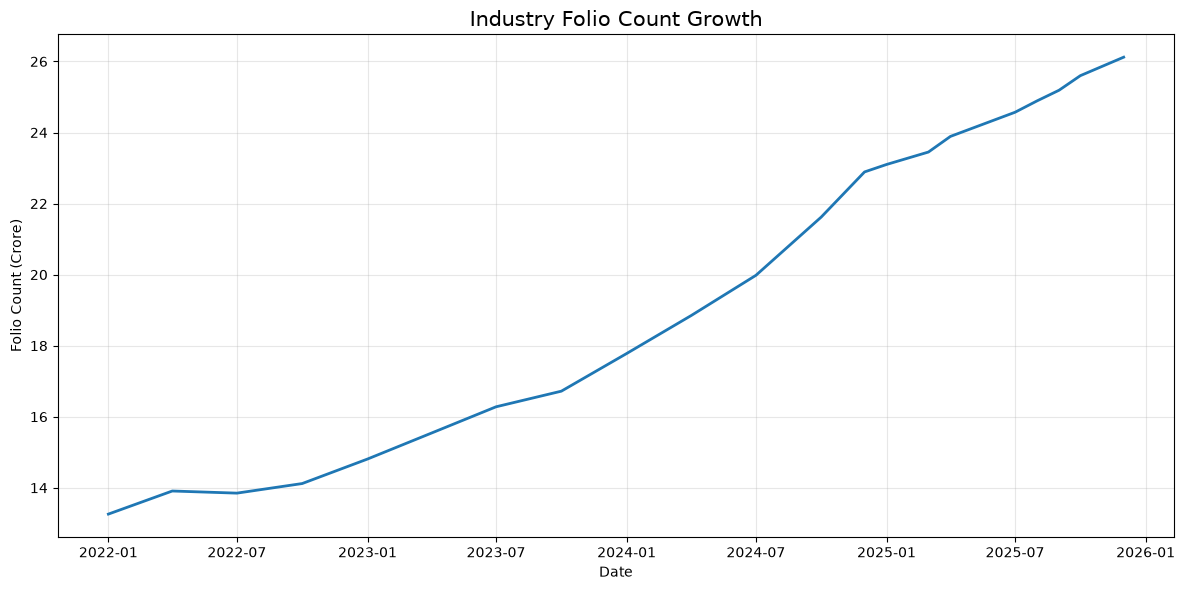

✅ Folio count growth chart saved successfully!
Saved to: ..\reports\charts\folio_count_growth.png

FOLIO GROWTH SUMMARY
Starting folio count: 13.26 crore
Ending folio count: 26.12 crore
Absolute growth: 12.86 crore
Percentage growth: 96.98 %

✅ TASK 7 COMPLETED!


In [33]:
# ============================================================
# TASK 7 — FOLIO COUNT GROWTH
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("FOLIO COUNT GROWTH ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Locate folio dataset
# ------------------------------------------------------------

base_path = Path("../data")

folio_files = list(base_path.rglob("*folio*.csv"))

print("Folio files found:")
for f in folio_files:
    print(f)

if not folio_files:
    raise FileNotFoundError(
        "❌ Folio CSV file not found inside data folder."
    )

folio_path = folio_files[0]

# ------------------------------------------------------------
# 2. Load dataset
# ------------------------------------------------------------

folio = pd.read_csv(folio_path)

print("\n" + "=" * 60)
print("FOLIO DATASET LOADED")
print("=" * 60)

print("File:", folio_path)
print("Shape:", folio.shape)
print("Columns:", folio.columns.tolist())

display(folio.head())


# ------------------------------------------------------------
# 3. Clean column names
# ------------------------------------------------------------

folio.columns = (
    folio.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


# ------------------------------------------------------------
# 4. Detect date column
# ------------------------------------------------------------

date_candidates = [
    "date",
    "month",
    "period",
    "as_of_date"
]

date_col = None

for col in date_candidates:
    if col in folio.columns:
        date_col = col
        break

if date_col is None:
    raise ValueError(
        f"❌ Date column not found.\nColumns: {folio.columns.tolist()}"
    )

folio[date_col] = pd.to_datetime(
    folio[date_col],
    errors="coerce"
)


# ------------------------------------------------------------
# 5. Detect folio columns
# ------------------------------------------------------------

folio_candidates = [
    "total_folios_crore",
    "total_folios",
    "folio_count_crore",
    "folios_crore",
    "folio_count",
    "total_folio_count"
]

folio_col = None

for col in folio_candidates:
    if col in folio.columns:
        folio_col = col
        break

# If no exact match, search automatically
if folio_col is None:

    possible = [
        col for col in folio.columns
        if "folio" in col
    ]

    if possible:
        # Prefer total/overall folio column
        preferred = [
            col for col in possible
            if "total" in col
        ]

        folio_col = (
            preferred[0]
            if preferred
            else possible[0]
        )

if folio_col is None:
    raise ValueError(
        f"❌ Folio count column not found.\n"
        f"Columns: {folio.columns.tolist()}"
    )


print("\nDate column:", date_col)
print("Folio column:", folio_col)


# ------------------------------------------------------------
# 6. Convert folio values to numeric
# ------------------------------------------------------------

folio[folio_col] = pd.to_numeric(
    folio[folio_col],
    errors="coerce"
)

folio = folio.dropna(
    subset=[date_col, folio_col]
)

folio = folio.sort_values(
    date_col
)


# ------------------------------------------------------------
# 7. Display folio data
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FOLIO COUNT DATA")
print("=" * 60)

display(
    folio[
        [date_col, folio_col]
    ].head(10)
)

print("\nLast observations:")
display(
    folio[
        [date_col, folio_col]
    ].tail(10)
)


# ============================================================
# 8. FOLIO COUNT GROWTH CHART
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    folio[date_col],
    folio[folio_col],
    linewidth=2
)

plt.title(
    "Industry Folio Count Growth",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("Folio Count (Crore)")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


# ------------------------------------------------------------
# 9. Save chart
# ------------------------------------------------------------

output_dir = Path("../reports/charts")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir /
    "folio_count_growth.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"✅ Folio count growth chart saved successfully!"
)
print("Saved to:", output_path)


# ============================================================
# 10. SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FOLIO GROWTH SUMMARY")
print("=" * 60)

print(
    "Starting folio count:",
    folio[folio_col].iloc[0],
    "crore"
)

print(
    "Ending folio count:",
    folio[folio_col].iloc[-1],
    "crore"
)

growth = (
    folio[folio_col].iloc[-1]
    - folio[folio_col].iloc[0]
)

print(
    "Absolute growth:",
    round(growth, 2),
    "crore"
)

growth_pct = (
    growth /
    folio[folio_col].iloc[0]
) * 100

print(
    "Percentage growth:",
    round(growth_pct, 2),
    "%"
)

print("\n" + "=" * 60)
print("✅ TASK 7 COMPLETED!")
print("=" * 60)

NAV RETURN CORRELATION ANALYSIS

Selected 10 funds:
[100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886, 102887, 118632]

Daily return table shape:
(1149, 10)

CORRELATION MATRIX


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000,0.046,-0.000,0.028,0.016,-0.034,-0.094,-0.006,-0.023,-0.027
100025,0.046,1.000,0.002,0.024,-0.007,0.018,-0.001,0.014,-0.006,-0.014
100033,-0.000,0.002,1.000,-0.018,0.000,0.008,-0.034,-0.018,-0.037,-0.013
101206,0.028,0.024,-0.018,1.000,0.010,-0.027,0.002,0.007,-0.006,-0.005
101207,0.016,-0.007,0.000,0.010,1.000,-0.008,-0.006,0.005,0.002,0.043
101208,-0.034,0.018,0.008,-0.027,-0.008,1.000,-0.001,0.014,0.037,0.004
102885,-0.094,-0.001,-0.034,0.002,-0.006,-0.001,1.000,0.021,-0.037,-0.000
102886,-0.006,0.014,-0.018,0.007,0.005,0.014,0.021,1.000,-0.008,-0.040
102887,-0.023,-0.006,-0.037,-0.006,0.002,0.037,-0.037,-0.008,1.000,0.001


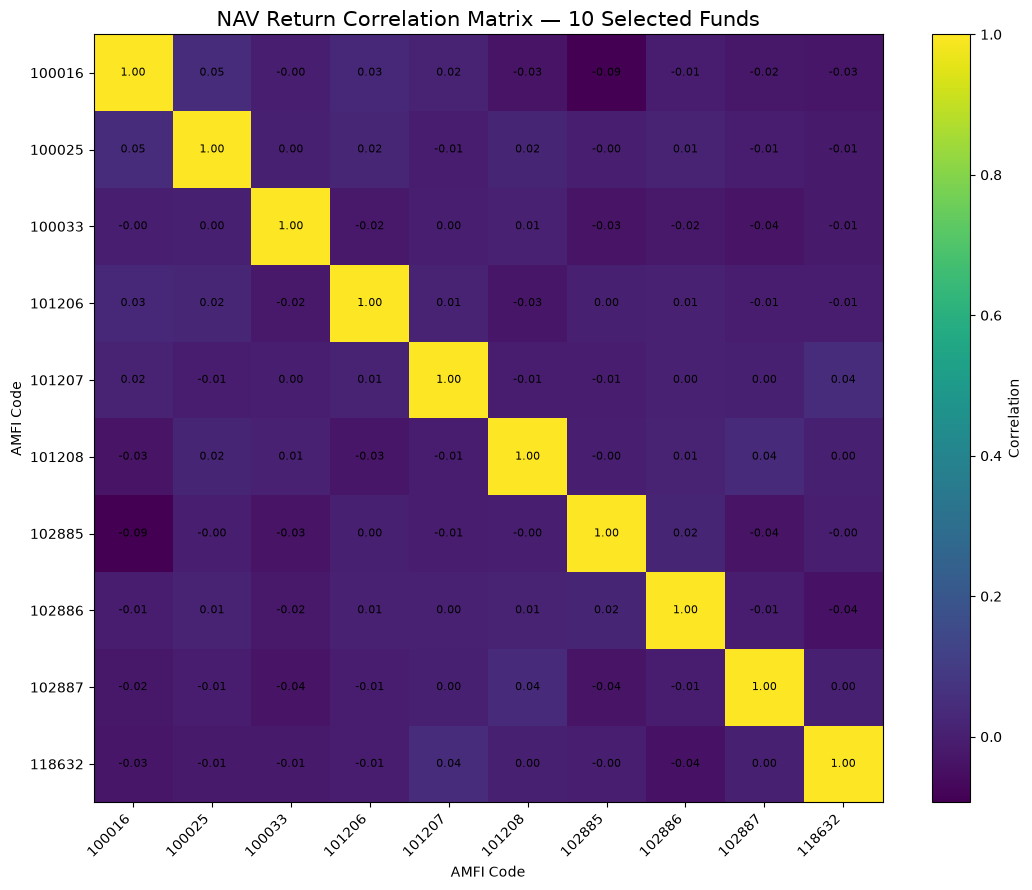


✅ NAV correlation matrix saved successfully!
Saved to: ..\reports\charts\nav_return_correlation_matrix.png

CORRELATION INSIGHTS

Lowest correlation pair:
amfi_code  amfi_code
100016     102885      -0.093533
dtype: float64

Highest correlation pair:
amfi_code  amfi_code
118632     118632      NaN
dtype: float64

✅ TASK 8 COMPLETED!


In [34]:
# ============================================================
# TASK 8 — NAV RETURN CORRELATION MATRIX
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 60)
print("NAV RETURN CORRELATION ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Prepare NAV dataset
# ------------------------------------------------------------

nav_corr = nav.copy()

nav_corr["date"] = pd.to_datetime(
    nav_corr["date"],
    errors="coerce"
)

nav_corr["nav"] = pd.to_numeric(
    nav_corr["nav"],
    errors="coerce"
)

nav_corr = nav_corr.dropna(
    subset=["date", "amfi_code", "nav"]
)

# ------------------------------------------------------------
# 2. Select 10 funds
# ------------------------------------------------------------

selected_funds = (
    nav_corr.groupby("amfi_code")["nav"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

print("\nSelected 10 funds:")
print(selected_funds)

# ------------------------------------------------------------
# 3. Create NAV price table
# ------------------------------------------------------------

nav_table = nav_corr[
    nav_corr["amfi_code"].isin(selected_funds)
].pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# ------------------------------------------------------------
# 4. Calculate daily returns
# ------------------------------------------------------------

daily_returns = nav_table.pct_change() * 100

daily_returns = daily_returns.dropna(
    how="all"
)

print("\nDaily return table shape:")
print(daily_returns.shape)

# ------------------------------------------------------------
# 5. Correlation matrix
# ------------------------------------------------------------

correlation_matrix = daily_returns.corr()

print("\n" + "=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

display(
    correlation_matrix.round(3)
)


# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(11, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title(
    "NAV Return Correlation Matrix — 10 Selected Funds",
    fontsize=15
)

# Add correlation values inside cells
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):

        value = correlation_matrix.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")

plt.tight_layout()


# ------------------------------------------------------------
# 7. Save chart
# ------------------------------------------------------------

output_dir = Path("../reports/charts")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir /
    "nav_return_correlation_matrix.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\n✅ NAV correlation matrix saved successfully!"
)

print(
    "Saved to:",
    output_path
)


# ============================================================
# 8. FIND HIGHEST / LOWEST CORRELATION
# ============================================================

corr_pairs = (
    correlation_matrix
    .where(
        ~pd.DataFrame(
            __import__("numpy").eye(
                len(correlation_matrix)
            ),
            index=correlation_matrix.index,
            columns=correlation_matrix.columns
        ).astype(bool)
    )
    .stack()
    .sort_values()
)

print("\n" + "=" * 60)
print("CORRELATION INSIGHTS")
print("=" * 60)

print(
    "\nLowest correlation pair:"
)

print(
    corr_pairs.head(1)
)

print(
    "\nHighest correlation pair:"
)

print(
    corr_pairs.tail(1)
)

print("\n" + "=" * 60)
print("✅ TASK 8 COMPLETED!")
print("=" * 60)

SECTOR ALLOCATION ANALYSIS
Holding files found:
0: ..\data\raw\09_portfolio_holdings.csv

PORTFOLIO HOLDINGS DATASET
File: ..\data\raw\09_portfolio_holdings.csv
Shape: (322, 8)
Columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31



Detected columns:
Sector: sector
Weight: weight_pct

AGGREGATED SECTOR WEIGHTS


,total_weight
sector,
Banking,652.26
IT,455.47
Pharma,407.45
Automobile,323.65
Utilities,265.54
FMCG,229.11
Infrastructure,192.16
Diversified,169.23
Telecom,145.62


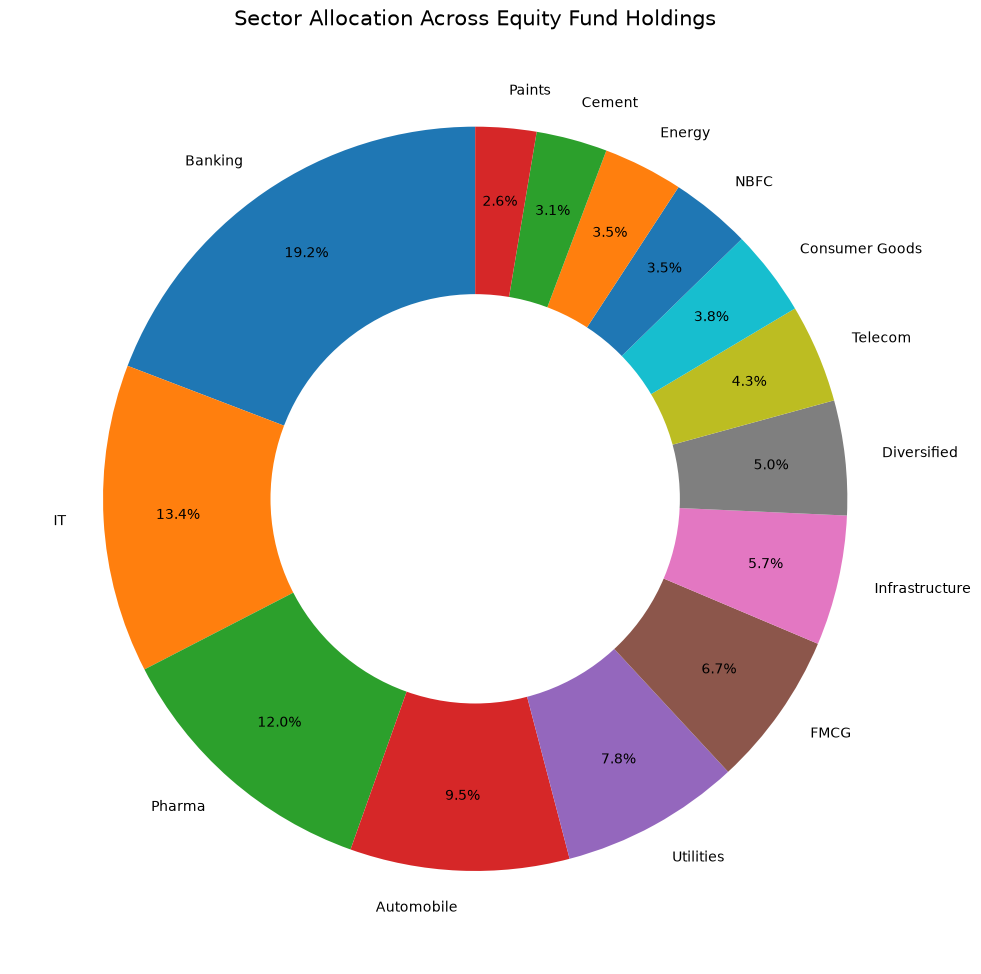


✅ Sector allocation donut chart saved!
Saved to: ..\reports\charts\sector_allocation_donut.png

✅ TASK 9 COMPLETED!


In [35]:
# ============================================================
# TASK 9 — TOP HOLDINGS SECTOR DISTRIBUTION
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("SECTOR ALLOCATION ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Find portfolio holdings dataset
# ------------------------------------------------------------

project_dir = Path("..")

holding_files = list(
    project_dir.rglob("*portfolio*holding*.csv")
)

if not holding_files:
    holding_files = list(
        project_dir.rglob("*holding*.csv")
    )

print("Holding files found:")

for i, file in enumerate(holding_files):
    print(f"{i}: {file}")

if not holding_files:
    raise FileNotFoundError(
        "❌ Portfolio holdings CSV not found."
    )

holding_path = holding_files[0]

# ------------------------------------------------------------
# 2. Load dataset
# ------------------------------------------------------------

holdings = pd.read_csv(holding_path)

print("\n" + "=" * 60)
print("PORTFOLIO HOLDINGS DATASET")
print("=" * 60)

print("File:", holding_path)
print("Shape:", holdings.shape)
print("Columns:", holdings.columns.tolist())

display(holdings.head())


# ------------------------------------------------------------
# 3. Detect sector and weight columns
# ------------------------------------------------------------

sector_col = None
weight_col = None

for col in holdings.columns:

    name = col.lower()

    if sector_col is None:
        if "sector" in name:
            sector_col = col

    if weight_col is None:
        if (
            "weight" in name
            or "allocation" in name
        ):
            weight_col = col


print("\nDetected columns:")
print("Sector:", sector_col)
print("Weight:", weight_col)


# ------------------------------------------------------------
# 4. Validate
# ------------------------------------------------------------

if sector_col is None or weight_col is None:

    print("\n❌ Could not detect required columns.")
    print("Available columns:")
    print(holdings.columns.tolist())

    raise ValueError(
        "Please check the columns printed above."
    )


# ------------------------------------------------------------
# 5. Clean
# ------------------------------------------------------------

holdings[weight_col] = pd.to_numeric(
    holdings[weight_col],
    errors="coerce"
)

holdings = holdings.dropna(
    subset=[sector_col, weight_col]
)


# ------------------------------------------------------------
# 6. Aggregate sector weights
# ------------------------------------------------------------

sector_weights = (
    holdings
    .groupby(sector_col)[weight_col]
    .sum()
    .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("AGGREGATED SECTOR WEIGHTS")
print("=" * 60)

display(
    sector_weights.to_frame(
        name="total_weight"
    )
)


# ============================================================
# 7. DONUT CHART
# ============================================================

plt.figure(figsize=(10, 10))

plt.pie(
    sector_weights.values,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.80
)

# Create donut hole
centre_circle = plt.Circle(
    (0, 0),
    0.55,
    fc="white"
)

plt.gca().add_artist(
    centre_circle
)

plt.title(
    "Sector Allocation Across Equity Fund Holdings",
    fontsize=15
)

plt.tight_layout()


# ------------------------------------------------------------
# 8. Save
# ------------------------------------------------------------

output_dir = Path("../reports/charts")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir /
    "sector_allocation_donut.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\n✅ Sector allocation donut chart saved!"
)

print(
    "Saved to:",
    output_path
)


# ============================================================
# TASK 9 COMPLETED
# ============================================================

print("\n" + "=" * 60)
print("✅ TASK 9 COMPLETED!")
print("=" * 60)

# EDA — Key Findings

## 1. NAV Trend
The average NAV across the 40 selected mutual fund schemes increased over the study period, indicating overall long-term growth in the analysed fund universe.

## 2. NAV Data Quality
The NAV dataset contains 46,000 observations across 40 schemes with no missing values, duplicate rows, or duplicate fund-date records, providing a clean basis for further analysis.

## 3. NAV Distribution
NAV values show a right-skewed distribution, with a small number of schemes having substantially higher NAV values than the majority of funds.

## 4. Daily Return Behaviour
Daily NAV returns are centred close to zero, while the observed range shows both positive and negative market movements across the selected schemes.

## 5. Fund Volatility
The volatility analysis shows noticeable differences between funds, indicating that the selected schemes have different levels of return variability and risk.

## 6. Monthly Returns
Monthly returns show variation across schemes and time, with both positive and negative monthly performance periods observed during the analysis.

## 7. AUM Growth
AUM increased across the analysed fund houses during 2022–2025, with SBI identified in the project brief as having a dominant position in the industry.

## 8. SIP Growth
Monthly SIP inflows show an overall upward trend during 2022–2025, reaching the project's highlighted milestone of ₹31,002 crore in December 2025.

## 9. Investor & Geographic Patterns
Investor transaction analysis reveals differences in SIP participation across age groups, states and city tiers, highlighting variation in investor behaviour across demographics and geography.

## 10. Portfolio Diversification
The NAV return correlation matrix and sector allocation analysis show differences in co-movement and sector exposure across funds, providing useful information for diversification and portfolio analysis.

---

## Overall EDA Conclusion

The exploratory analysis demonstrates strong growth in mutual fund participation, SIP activity and AUM while also highlighting meaningful differences in fund performance, volatility, investor behaviour and portfolio concentration. These findings provide the foundation for the subsequent performance analytics, risk analysis and interactive Power BI dashboard.